<!-- KERNEL_BANNER -->
> **Use kernel: `mrigi_tor190_v8`**
>
> Set the notebook kernel to *Python (mrigi_tor190_v8)* before running.

# 30e: Paper figures from the dual-judge open-ended evaluation

**Read-only. Makes no OpenAI API calls.** Everything is computed from
`judge_results_23j_dual_final_20260802_184737.json`.

Models are labelled with the **Table 1** names. All 9 open-weight Table 1 rows are
present; GPT-5.2 (row 1) was never run through the generation pipeline and is
therefore absent from every figure.

**Figures produced**

| # | Figure | Question it answers |
|---|---|---|
| 1 | Correctness by model × retrieval condition | Which variant answers most correctly? |
| 2 | Correctness + completeness side by side | Does the ranking hold across metrics? |
| 3 | CoT effect (paired dumbbell) | How much does CoT FT move each base checkpoint? |
| 4 | CoT delta by metric | How large is the CoT gain, and is it significant? |
| 5 | Judge agreement, GPT-4.1 vs GPT-4o | Is the measurement instrument stable? |

**Metrics reported: correctness and completeness only.** Faithfulness and context
relevance are excluded — context relevance is identical across models by construction
(one shared retriever), and faithfulness has the weakest inter-judge agreement of the
four tasks. Both remain in the source JSON.

Each figure is written to both `.svg` (vector, for LaTeX) and `.png` (300 dpi).

In [1]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import wilcoxon, pearsonr
from datetime import datetime

# ---------------------------------------------------------------------------
# Prefer the CLEAN judge file written by 30g (answers with the echoed prompt
# stripped). Fall back to the older dual-judge file only if no clean file exists.
#
# The two files have different shapes, so both are normalised here into
#     SCORES[model][condition][q_idx][judge][task] = int
#   clean-extraction-v1 : results["model|cond|i"][judge][task]["score"]
#   dual-judge-v1       : results[model][cond][i]["judges"][judge]["<task>_score"]
# ---------------------------------------------------------------------------
JUDGE_FILE = None
if JUDGE_FILE is None:
    clean_files = sorted(glob.glob('judge_results_23j_clean_*.json'), key=os.path.getmtime)
    dual_files  = sorted(glob.glob('judge_results_23j_dual_final_*.json'), key=os.path.getmtime)
    JUDGE_FILE = clean_files[-1] if clean_files else (dual_files[-1] if dual_files else None)
if JUDGE_FILE is None:
    raise FileNotFoundError('No judge results found - run 30g (or 30b) first.')

_payload = json.load(open(JUDGE_FILE))
META = _payload.get('metadata', {})
_raw = _payload['results']
SCHEMA = META.get('schema', 'dual-judge-v1')

TASKS = ['correctness', 'completeness']
TASK_TITLE = {'correctness': 'Correctness', 'completeness': 'Completeness'}
COND_TITLE = {'no_context': 'No context', 'mmr': 'RAG (MMR, k=15)'}

SCORES = {}
if SCHEMA == 'clean-extraction-v1':
    JUDGES = META['judges']
    for key, per_judge in _raw.items():
        m, c, i = key.rsplit('|', 2)
        SCORES.setdefault(m, {}).setdefault(c, {})[int(i)] = {
            j: {t: per_judge[j][t]['score'] for t in TASKS} for j in JUDGES}
else:
    JUDGES = META.get('judge_models', ['gpt-4.1', 'gpt-4o'])
    for m, conds in _raw.items():
        for c, recs in conds.items():
            if c not in ('no_context', 'mmr'):
                continue
            for i, r in enumerate(recs or []):
                if not r:
                    continue
                SCORES.setdefault(m, {}).setdefault(c, {})[i] = {
                    j: {t: r['judges'][j][f'{t}_score'] for t in TASKS} for j in JUDGES}

TS = datetime.now().strftime('%Y%m%d_%H%M%S')
FIGDIR = 'figures_30e'
os.makedirs(FIGDIR, exist_ok=True)

print(f'source : {JUDGE_FILE}')
print(f'schema : {SCHEMA}')
print(f'judges : {JUDGES}')
print(f'models : {len(SCORES)}')
print(f'figures -> {FIGDIR}/   (one set per judge)')

source : judge_results_23j_clean_20260803_201225.json
schema : clean-extraction-v1
judges : ['gpt-4o', 'gpt-4.1']
models : 9
figures -> figures_30e/   (one set per judge)


In [2]:
# ---------------------------------------------------------------------------
# Table 1 -> internal name mapping.
# `plot_label` is the short form used on axes; `table_label` is the verbatim
# Table 1 text, carried into the exported CSVs so figures and paper agree.
# ---------------------------------------------------------------------------
TABLE1 = [
    # (table_label, plot_label, internal_name, dapt_corpus, cot_ft, pair_group)
    ('GPT-5.2',
     'GPT-5.2', None, 'None', False, None),
    ('Llama-3-8B-Instruct',
     'Llama-3-8B-Instruct', 'Llama-3-8B-Instruct', 'None', False, 'instruct'),
    ('Llama-3-8B-Instruct + CoT FT',
     'Llama-3-8B-Instruct', 'base_llama_COT', 'None', True, 'instruct'),
    ('Llama-3-8B-Instruct, broad zeolite abstracts DAPT',
     'Broad abstracts DAPT', 'DAPT_LR1e5', 'Broad zeolite abstracts', False, 'broad'),
    ('Llama-3-8B-Instruct, broad zeolite abstracts DAPT + CoT FT',
     'Broad abstracts DAPT', 'DAPT_LR1e5_COT', 'Broad zeolite abstracts', True, 'broad'),
    ('Llama-3-8B-Instruct, synthesis abstracts DAPT',
     'Synthesis abstracts DAPT', 'synv2V2_step80', 'Synthesis abstracts', False, 'synth'),
    ('Llama-3-8B-Instruct, synthesis abstracts DAPT + CoT FT',
     'Synthesis abstracts DAPT', 'synv2V2_step80_COT', 'Synthesis abstracts', True, 'synth'),
    ('Llama-3-8B base, synthesis abstracts DAPT + CoT FT',
     'Synthesis abstracts DAPT\n(base LM)', 'synv2_base_step80_COT', 'Synthesis abstracts', True, None),
    ('Llama-3-8B-Instruct, synthesis full-paper DAPT',
     'Synthesis full-paper DAPT', 'fullpaper_120M_LR1e5', 'Synthesis full papers', False, 'fullpaper'),
    ('Llama-3-8B-Instruct, synthesis full-paper DAPT + CoT FT',
     'Synthesis full-paper DAPT', 'fullpaper_120M_COT', 'Synthesis full papers', True, 'fullpaper'),
]

meta_rows = []
for tl, pl, nm, corpus, cot, grp in TABLE1:
    meta_rows.append({
        'table_label': tl, 'plot_label': pl, 'internal': nm,
        'dapt_corpus': corpus, 'cot_ft': cot, 'pair_group': grp,
        'in_results': (nm is not None and nm in SCORES),
    })
MODEL_META = pd.DataFrame(meta_rows)

AVAILABLE = MODEL_META[MODEL_META['in_results']].reset_index(drop=True)
MISSING   = MODEL_META[~MODEL_META['in_results']].reset_index(drop=True)

print(f'Table 1 rows plotted : {len(AVAILABLE)} / {len(MODEL_META)}')
for _, r in MISSING.iterrows():
    print(f'   EXCLUDED  {r.table_label}  (no generation results in the pipeline)')

# CoT pairs = groups that have both a CoT and a non-CoT member present
PAIRS = []
for grp, sub in AVAILABLE.groupby('pair_group'):
    base = sub[~sub['cot_ft']]
    cot  = sub[sub['cot_ft']]
    if len(base) == 1 and len(cot) == 1:
        PAIRS.append({
            'group': grp,
            'label': base.iloc[0]['plot_label'],
            'base': base.iloc[0]['internal'],
            'cot':  cot.iloc[0]['internal'],
        })
# keep Table 1 ordering
_order = [g for g in MODEL_META['pair_group'].tolist() if g]
PAIRS.sort(key=lambda d: _order.index(d['group']))
print(f'\nCoT / non-CoT pairs available: {len(PAIRS)}')
for p in PAIRS:
    print(f"   {p['base']:<24} -> {p['cot']}")

Table 1 rows plotted : 9 / 10
   EXCLUDED  GPT-5.2  (no generation results in the pipeline)

CoT / non-CoT pairs available: 4
   Llama-3-8B-Instruct      -> base_llama_COT
   DAPT_LR1e5               -> DAPT_LR1e5_COT
   synv2V2_step80           -> synv2V2_step80_COT
   fullpaper_120M_LR1e5     -> fullpaper_120M_COT


In [3]:
# ---------------------------------------------------------------------------
# Design language: geometric sans (Montserrat), muted terracotta/steel-blue,
# minimal chrome (no gridlines, no y-spine, single bottom rule), bold value
# labels colour-matched to their bar, and grey "reference" rows separated by a
# horizontal rule from the main comparison group.
# ---------------------------------------------------------------------------
ORANGE = '#D2782F'   # RAG (MMR, k=15)
BLUE   = '#4A7EBB'   # No context
GREY   = '#8C8C8C'   # reference / baseline rows
INK    = '#1A1A1A'
MUTED  = '#7A7A7A'
RULE   = '#D8D8D8'

COND_COLOR = {'no_context': BLUE, 'mmr': ORANGE}
COND_SHORT = {'no_context': 'no context', 'mmr': 'RAG k=15'}

FONT = 'Montserrat'
mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': FONT, 'font.size': 11,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'axes.edgecolor': INK, 'axes.labelcolor': MUTED, 'axes.linewidth': 1.4,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'xtick.color': MUTED, 'ytick.color': INK,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'xtick.major.size': 0, 'ytick.major.size': 0,
    'legend.frameon': False, 'legend.fontsize': 10,
    'axes.grid': False,
})


def strip(ax):
    """Reference-style chrome: bottom rule only, no ticks, no grid."""
    ax.grid(False)
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color(INK)
    ax.spines['bottom'].set_linewidth(1.4)
    ax.tick_params(axis='both', length=0)
    return ax


def xlim_for(vals, pad_lo=0.55, pad_hi=0.85):
    """Truncated x-range matching the reference look. Values are always printed
    at the bar end, and the axis start is stated in the caption."""
    v = np.asarray([x for x in vals if np.isfinite(x)], float)
    return float(np.floor((v.min() - pad_lo) * 2) / 2), float(v.max() + pad_hi)


def value_label(ax, x, y, val, color, dx=0.06):
    ax.text(x + dx, y, f'{val:.2f}', va='center', ha='left',
            fontsize=10.5, fontweight='bold', color=color, zorder=6)


def save(fig, name):
    for ext in ('svg', 'png'):
        fig.savefig(os.path.join(FIGDIR, f'{name}_{TS}.{ext}'), format=ext)
    print(f'  saved {FIGDIR}/{name}_{TS}.{{svg,png}}')


print(f'style configured  (font: {FONT})')

style configured  (font: Montserrat)


## Long-form score table

One row per (model, condition, judge, question). Everything downstream is an
aggregation of this frame, so the figures and the exported CSVs cannot disagree.

In [4]:
rows = []
for _, m in AVAILABLE.iterrows():
    for cond in ('no_context', 'mmr'):
        for q_idx, per_judge in SCORES.get(m.internal, {}).get(cond, {}).items():
            for j in JUDGES:
                row = {'table_label': m.table_label, 'plot_label': m.plot_label,
                       'internal': m.internal, 'dapt_corpus': m.dapt_corpus,
                       'cot_ft': m.cot_ft, 'pair_group': m.pair_group,
                       'condition': cond, 'judge': j, 'q_idx': q_idx}
                for t in TASKS:
                    s = per_judge[j][t]
                    row[t] = s if s > 0 else np.nan
                rows.append(row)

long_df = pd.DataFrame(rows)
print(f'long_df: {len(long_df):,} rows  ({len(AVAILABLE)} models x 2 conditions x {len(JUDGES)} judges)')

agg = (long_df
       .groupby(['table_label', 'plot_label', 'internal', 'dapt_corpus',
                 'cot_ft', 'pair_group', 'condition', 'judge'], dropna=False)[TASKS]
       .agg(['mean', 'sem', 'count']))
agg.columns = [f'{a}_{b}' for a, b in agg.columns]
agg = agg.reset_index()
agg.to_csv(os.path.join(FIGDIR, f'summary_by_model_{TS}.csv'), index=False)
print(f'saved {FIGDIR}/summary_by_model_{TS}.csv')

cov = long_df.groupby(['plot_label', 'cot_ft', 'condition', 'judge'])['correctness'].agg(valid='count', total='size')
cov['pct'] = (cov.valid / cov.total * 100).round(1)
low = cov[cov.pct < 95]
if len(low):
    print('\nNOTE - cells below 95% valid correctness scores:')
    print(low.to_string())

long_df: 3,600 rows  (9 models x 2 conditions x 2 judges)
saved figures_30e/summary_by_model_20260811_193811.csv

NOTE - cells below 95% valid correctness scores:
                                                              valid  total   pct
plot_label                          cot_ft condition judge                      
Synthesis abstracts DAPT\n(base LM) True   mmr       gpt-4.1     91    100  91.0
                                                     gpt-4o      91    100  91.0


## Figure 1 — Correctness by model and retrieval condition

Horizontal bars: the Table 1 labels are long, and horizontal layout keeps them
readable without rotation. Table 1 ordering is preserved (rather than sorting by
score) so each base / +CoT pair stays adjacent. Error bars are ±1 SEM.

replicate: judge_results_23M_20260811_175959.json  (judge gpt-4o)
   no_context  7.26 +/- 0.16  (n=100)
   mmr         7.30 +/- 0.17  (n=100)
  saved figures_30e/fig1_correctness_gpt-4o_20260811_193811.{svg,png}


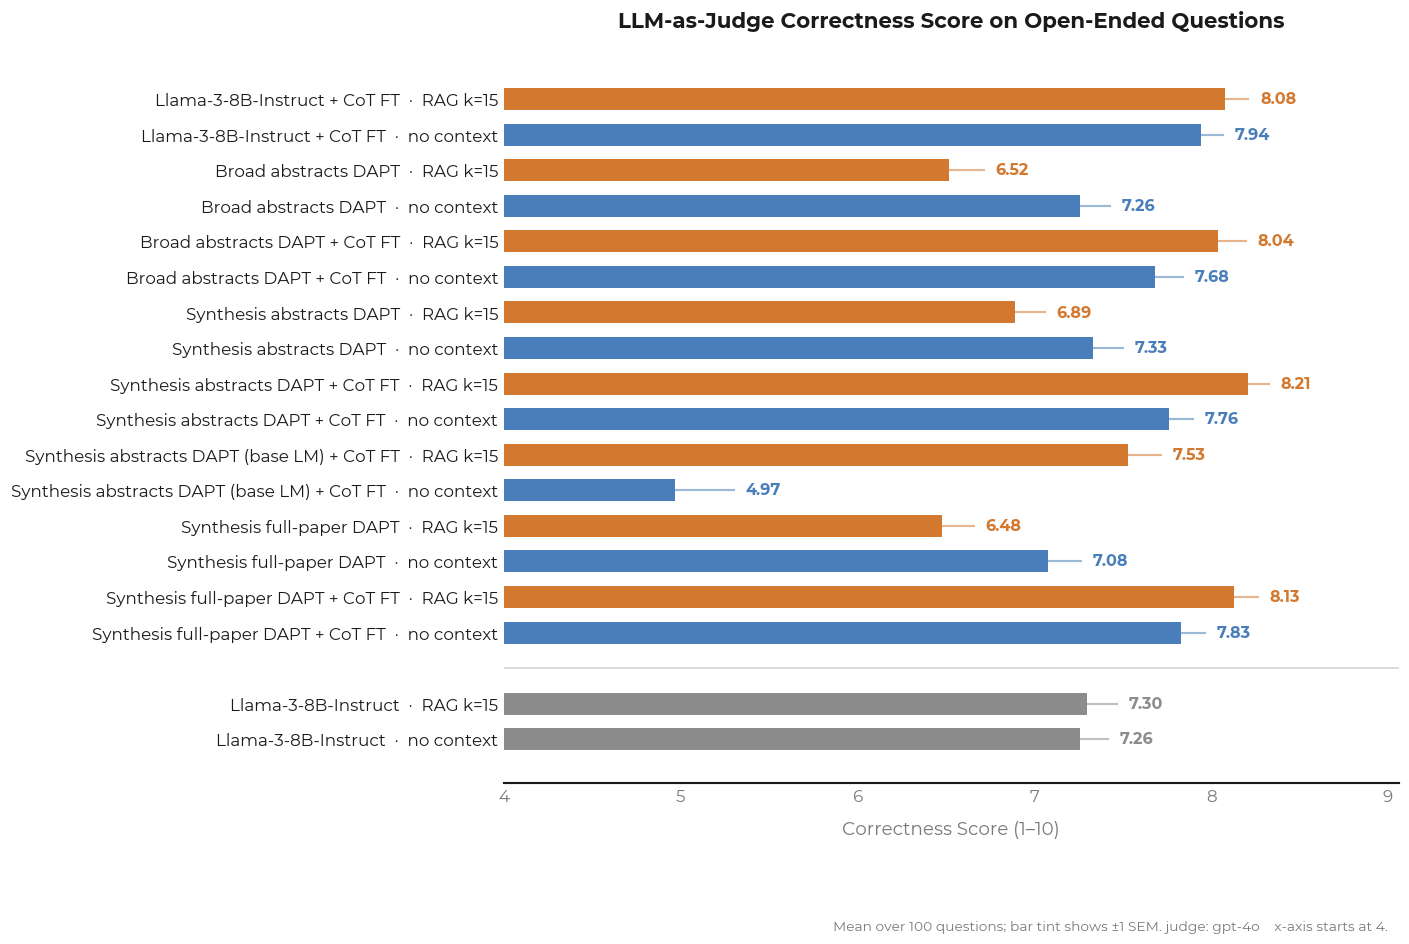

  saved figures_30e/fig1_correctness_gpt-4.1_20260811_193811.{svg,png}


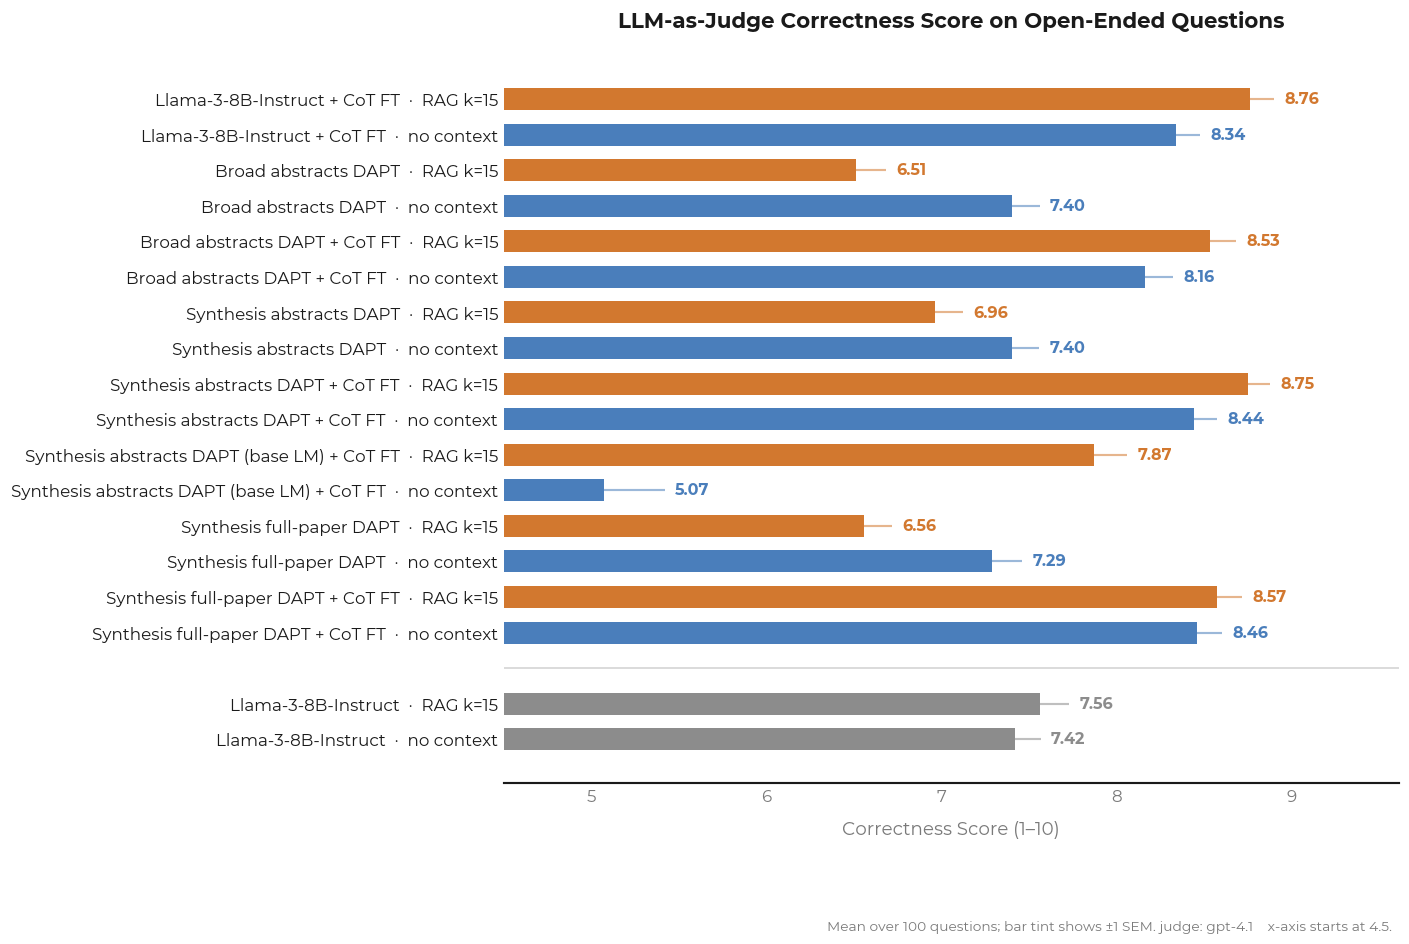

In [13]:
# ---------------------------------------------------------------------------
# Replicate override (notebook 23M).
#
# 23M re-ran stock Llama-3-8B-Instruct on the identical 100 questions with the
# fixed extractor and re-judged correctness with gpt-4o. Those values supersede
# the original run for the grey reference rows of Figure 1 only:
#   - 23M judged CORRECTNESS only, so completeness has no replicate and Figure 2
#     stays on the original numbers;
#   - Figures 3-4 use Llama as a CoT-pair base, and substituting one run's scores
#     into a paired comparison would mix runs, so they are left untouched.
# Set USE_REPLICATE = False to fall back to the original values everywhere.
# ---------------------------------------------------------------------------
USE_REPLICATE = True
REPLICATE = {}
_rep_files = sorted(glob.glob('judge_results_23M_*.json'), key=os.path.getmtime)
if USE_REPLICATE and _rep_files:
    _rp = json.load(open(_rep_files[-1]))
    for _c in ('no_context', 'mmr'):
        _v = [s_ for k_, s_ in _rp['results'].items() if k_.startswith(_c + '|') and s_ > 0]
        if _v:
            REPLICATE[('Llama-3-8B-Instruct', _c, 'correctness')] = (
                float(np.mean(_v)), float(np.std(_v, ddof=1) / np.sqrt(len(_v))), len(_v))
    print(f'replicate: {_rep_files[-1]}  (judge {_rp["judge"]})')
    for _k, _val in REPLICATE.items():
        print(f'   {_k[1]:<11} {_val[0]:.2f} +/- {_val[1]:.2f}  (n={_val[2]})')
else:
    print('no replicate applied - original run used throughout')

# Stock Llama-3-8B-Instruct is the reference point; grey, below a rule.
REFERENCE = 'Llama-3-8B-Instruct'
main_df = AVAILABLE[AVAILABLE.internal != REFERENCE]
ref_df  = AVAILABLE[AVAILABLE.internal == REFERENCE]


def score(internal, cond, task, judge, use_replicate=False):
    if use_replicate and (internal, cond, task) in REPLICATE:
        m_, s_, _ = REPLICATE[(internal, cond, task)]
        return m_, s_
    c = agg[(agg.internal == internal) & (agg.condition == cond) & (agg.judge == judge)]
    if not len(c):
        return np.nan, np.nan
    return float(c[f'{task}_mean'].iloc[0]), float(c[f'{task}_sem'].iloc[0])


def row_label(m, cond):
    base = m.plot_label.replace('\n', ' ')
    if m.cot_ft:
        base += ' + CoT FT'
    return f'{base}  \u00b7  {COND_SHORT[cond]}'


def draw_split(ax, task, judge, conditions=('mmr', 'no_context'), use_replicate=False):
    """Main models on top, a rule, then the grey reference model.
    `conditions` selects which retrieval conditions to draw (in row order)."""
    labels, vals, sems, colors = [], [], [], []
    for _, m in main_df.iterrows():
        for cond in conditions:
            v, s = score(m.internal, cond, task, judge)
            labels.append(row_label(m, cond)); vals.append(v); sems.append(s)
            colors.append(COND_COLOR[cond])
    gap = len(vals)
    labels.append(''); vals.append(np.nan); sems.append(np.nan); colors.append('none')
    for _, m in ref_df.iterrows():
        for cond in conditions:
            v, s = score(m.internal, cond, task, judge, use_replicate=use_replicate)
            labels.append(row_label(m, cond)); vals.append(v); sems.append(s)
            colors.append(GREY)

    y = np.arange(len(vals))
    ax.barh(y, vals, height=0.62, color=colors, zorder=3)
    lo, hi = xlim_for([v for v in vals if np.isfinite(v)])
    for yi, v, s, c in zip(y, vals, sems, colors):
        if np.isfinite(v):
            ax.errorbar(v, yi, xerr=s, fmt='none', ecolor=c, elinewidth=1.4,
                        capsize=0, alpha=0.55, zorder=4)
            value_label(ax, v + (s if np.isfinite(s) else 0), yi, v, c)
    ax.axhline(gap, color=RULE, linewidth=1.2, zorder=2)
    ax.set_yticks(y); ax.set_yticklabels(labels)
    ax.set_xlim(lo, hi); ax.invert_yaxis()
    strip(ax)
    return lo


# one figure per judge
for JUDGE in JUDGES:
    fig, ax = plt.subplots(figsize=(10.5, 8.6))
    lo = draw_split(ax, 'correctness', JUDGE, use_replicate=(JUDGE == 'gpt-4o'))
    ax.set_xlabel('Correctness Score (1\u201310)', labelpad=10)
    ax.set_title(f'LLM-as-Judge Correctness Score on Open-Ended Questions',
                 fontweight='bold', color=INK, pad=18)
    fig.text(0.65, -0.045,
             f'Mean over 100 questions; bar tint shows \u00b11 SEM. judge: {JUDGE}  '
             + f'  x-axis starts at {lo:g}.',
             fontsize=9, color=MUTED, ha='center')
    save(fig, f'fig1_correctness_{JUDGE}')
    plt.show()

## Figure 2 — All four judge metrics

Same encoding as Figure 1, faceted over metrics, so the ranking can be checked for
consistency. Context relevance is a property of the retriever and is undefined
without context, so its no-context series is empty by construction.

  saved figures_30e/fig2_all_metrics_gpt-4o_20260811_193811.{svg,png}


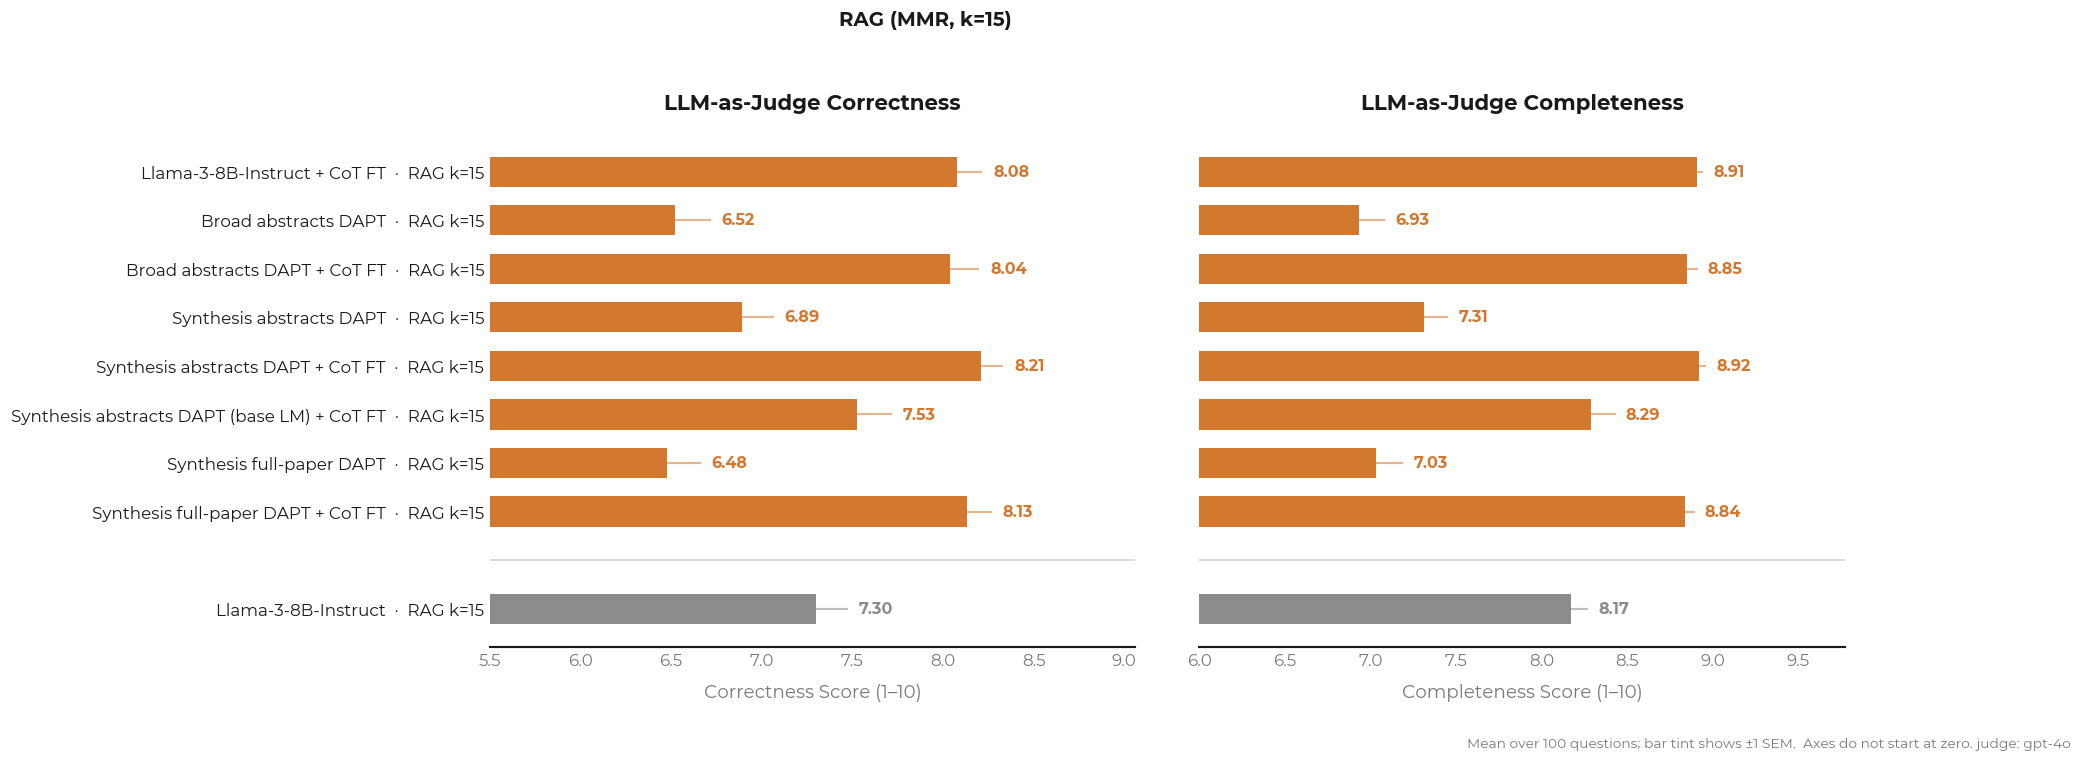

  saved figures_30e/fig2_all_metrics_gpt-4.1_20260811_193811.{svg,png}


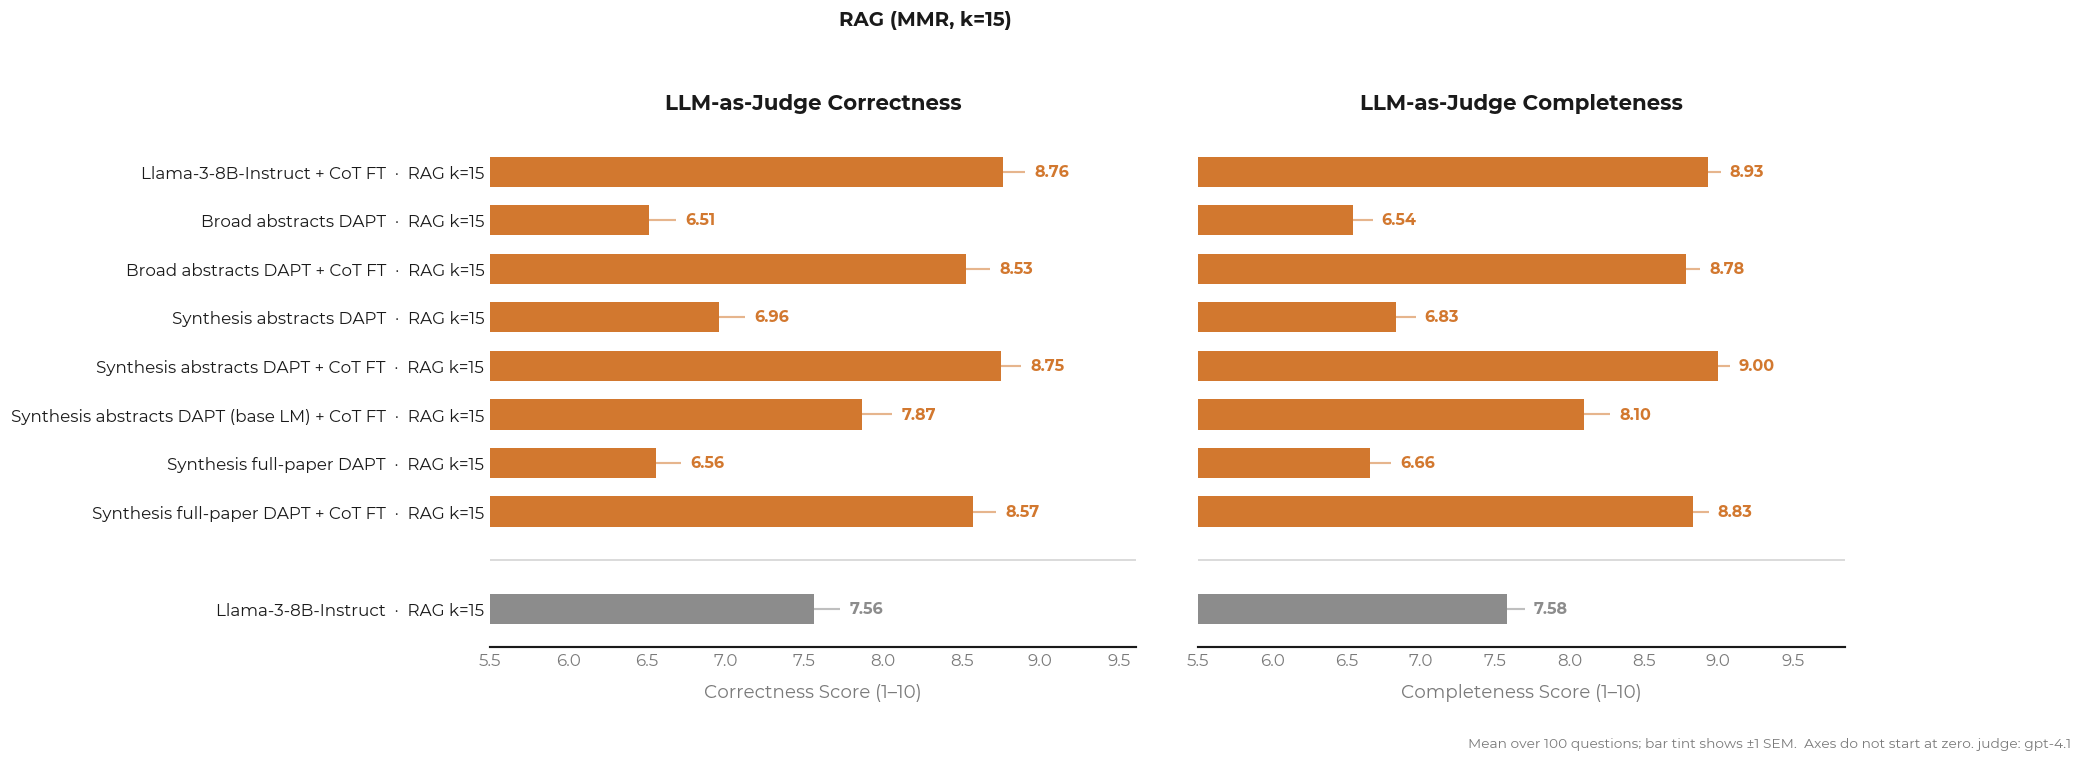

In [ ]:
# RAG (MMR k=15) only - the no-context bars are dropped here; Figure 1 still shows both.
for JUDGE in JUDGES:
    fig, axes = plt.subplots(1, 2, figsize=(17, 6.2))
    for ax, task in zip(axes, TASKS):
        lo = draw_split(ax, task, JUDGE, conditions=('mmr',),
                        use_replicate=(JUDGE == 'gpt-4o'))
        ax.set_xlabel(f'{TASK_TITLE[task]} Score (1\u201310)', labelpad=10)
        ax.set_title(f'LLM-as-Judge {TASK_TITLE[task]}', fontweight='bold', color=INK, pad=16)
    axes[1].set_yticklabels([])
    fig.suptitle(f'RAG (MMR, k=15) on Open-Ended Questions',
                 fontweight='bold', color=INK, y=1.04, fontsize=13)
    # 23M re-judged CORRECTNESS only, so the grey reference row draws its correctness
    # from the replicate and its completeness from the original run. Say so explicitly.
    _note = ('  Grey row = stock Llama-3-8B-Instruct reference '
             '(correctness from the 23M replicate; completeness from the original run).'
             if (JUDGE == 'gpt-4o' and REPLICATE)
             else '  Grey row = stock Llama-3-8B-Instruct reference.')
    fig.text(0.95, -0.04,
             'Mean over 100 questions; bar tint shows \u00b11 SEM.' 
             + f'  Axes do not start at zero. judge: {JUDGE}',
             fontsize=9, color=MUTED, ha='center')
    fig.tight_layout(w_pad=3)


    save(fig, f'fig2_all_metrics_{JUDGE}')
    plt.show()

## Figure 3 — The CoT effect, per base checkpoint

A dumbbell shows both the absolute levels and the size of the shift, which a bar
chart of deltas alone would hide. Each row is one base checkpoint; the connector
runs from the base model to its `+ CoT FT` variant.

  saved figures_30e/fig3_cot_dumbbell_gpt-4o_20260811_193811.{svg,png}


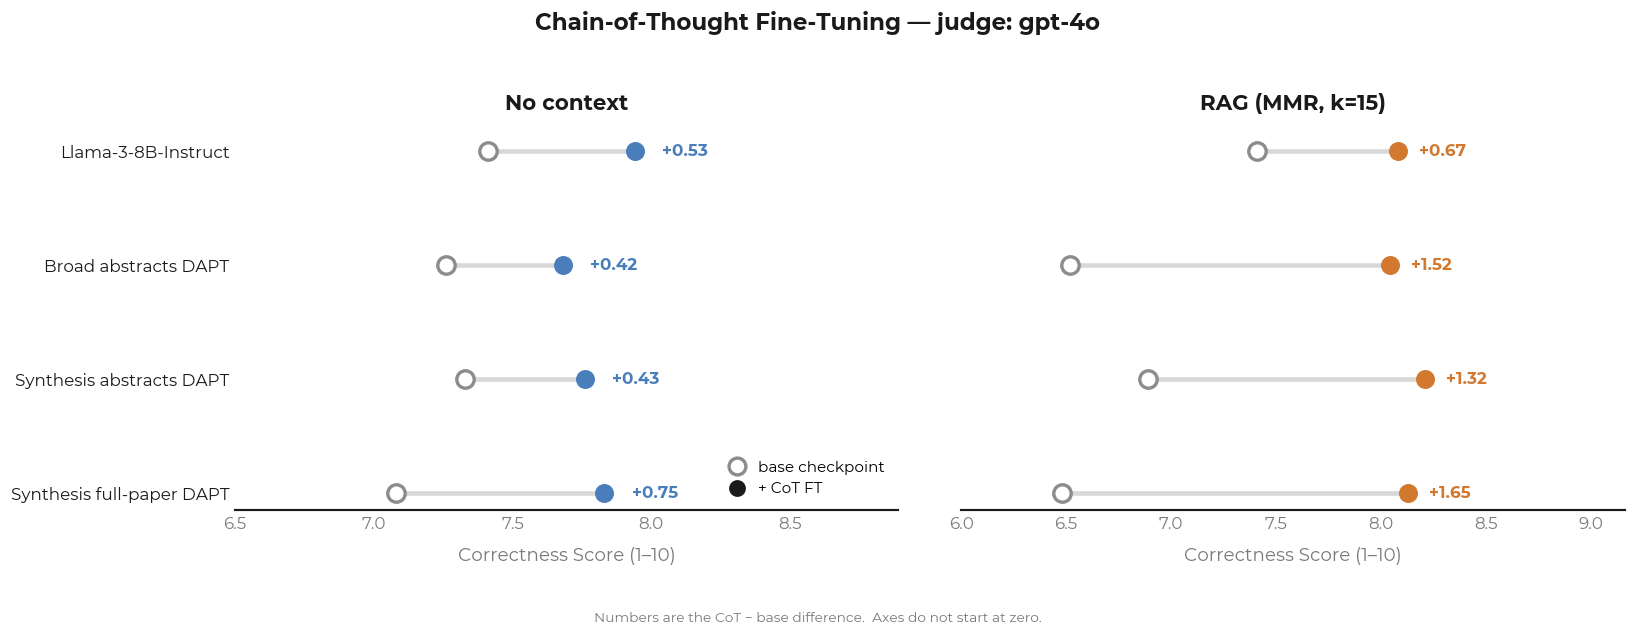

  saved figures_30e/fig3_cot_dumbbell_gpt-4.1_20260811_193811.{svg,png}


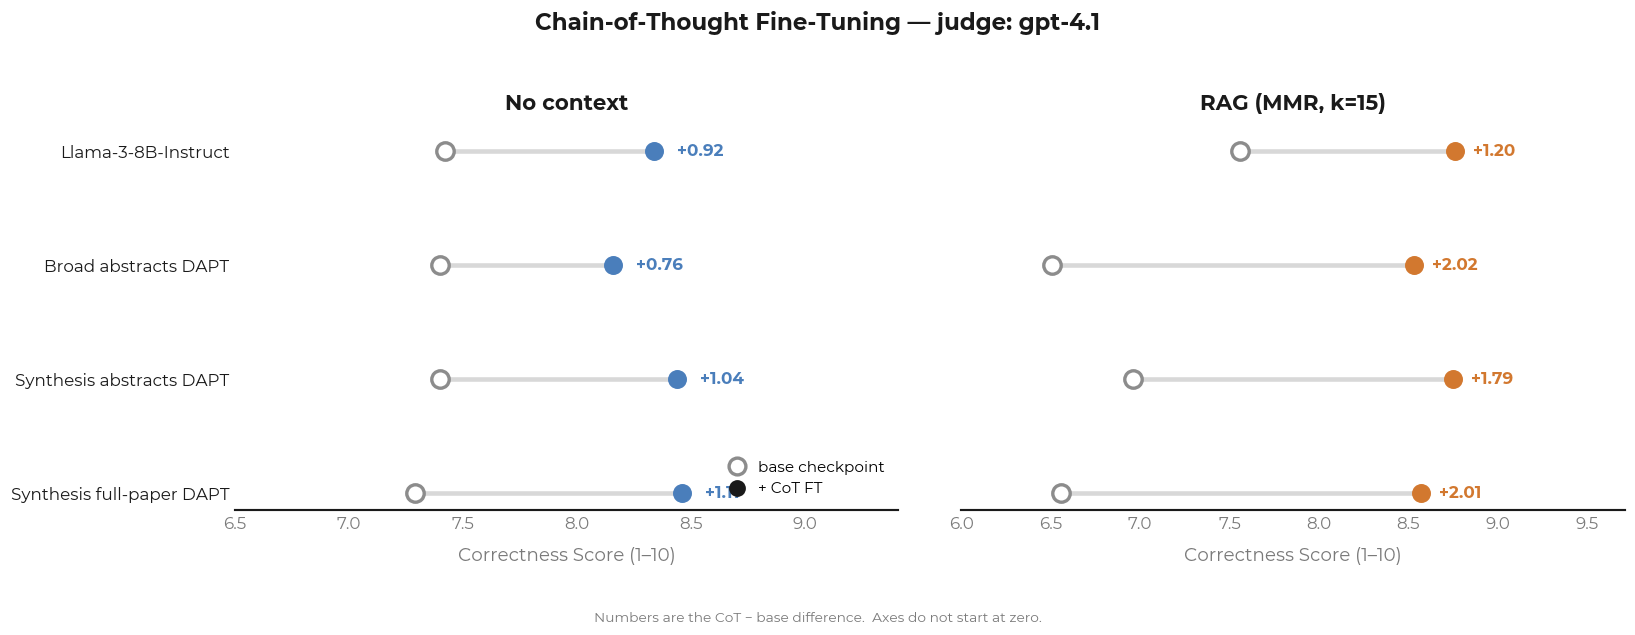

In [7]:
def cell_mean(internal, cond, task, judge):
    return score(internal, cond, task, judge)[0]


for JUDGE in JUDGES:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.0))
    for ax, cond in zip(axes, ('no_context', 'mmr')):
        col = COND_COLOR[cond]
        for i, p in enumerate(PAIRS):
            b = cell_mean(p['base'], cond, 'correctness', JUDGE)
            c = cell_mean(p['cot'],  cond, 'correctness', JUDGE)
            ax.plot([b, c], [i, i], color=RULE, linewidth=3.0, solid_capstyle='round', zorder=2)
            ax.scatter([b], [i], s=130, facecolor='white', edgecolor=GREY, linewidth=2.2, zorder=3)
            ax.scatter([c], [i], s=130, color=col, zorder=4)
            ax.text(max(b, c) + 0.10, i, f'{c - b:+.2f}', va='center', ha='left',
                    fontsize=11, fontweight='bold', color=col, zorder=5)
        ax.set_yticks(range(len(PAIRS)))
        ax.set_yticklabels([p['label'].replace('\n', ' ') for p in PAIRS])
        vals = [cell_mean(p[k], cond, 'correctness', JUDGE) for p in PAIRS for k in ('base', 'cot')]
        lo, hi = xlim_for(vals, pad_lo=0.45, pad_hi=0.95)
        ax.set_xlim(lo, hi); ax.invert_yaxis(); strip(ax)
        ax.set_xlabel('Correctness Score (1\u201310)', labelpad=10)
        ax.set_title(COND_TITLE[cond], fontweight='bold', color=INK, pad=16)
    axes[1].set_yticklabels([])

    handles = [Line2D([], [], marker='o', linestyle='none', markersize=11,
                      markerfacecolor='white', markeredgecolor=GREY, markeredgewidth=2.2,
                      label='base checkpoint'),
               Line2D([], [], marker='o', linestyle='none', markersize=11,
                      markerfacecolor=INK, markeredgecolor='none', label='+ CoT FT')]
    axes[0].legend(handles=handles, loc='lower right', handletextpad=0.4)
    fig.suptitle(f'Chain-of-Thought Fine-Tuning \u2014 judge: {JUDGE}',
                 fontweight='bold', color=INK, y=1.04, fontsize=15)
    fig.text(0.5, -0.07,
             'Numbers are the CoT \u2212 base difference.  Axes do not start at zero.',
             fontsize=9, color=MUTED, ha='center')
    fig.tight_layout(w_pad=3)
    save(fig, f'fig3_cot_dumbbell_{JUDGE}')
    plt.show()

## Figure 4 — Where CoT helps and where it costs

Per-question paired differences (CoT − base on matched questions), so this is a
within-question contrast rather than a difference of independent means.
Diverging colour encodes sign: blue = CoT better, red = CoT worse.
Significance from a Wilcoxon signed-rank test.

saved figures_30e/cot_paired_deltas_20260811_193811.csv
  saved figures_30e/fig4_cot_deltas_gpt-4o_20260811_193811.{svg,png}


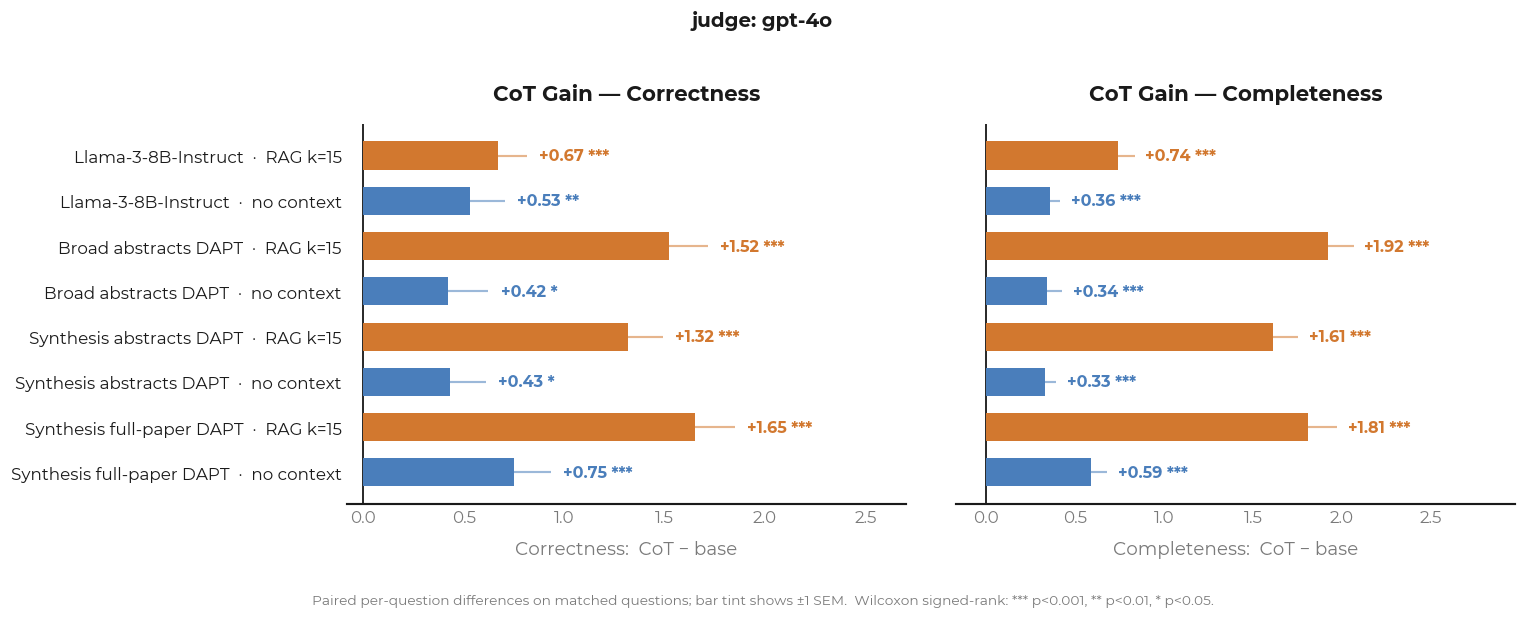

  saved figures_30e/fig4_cot_deltas_gpt-4.1_20260811_193811.{svg,png}


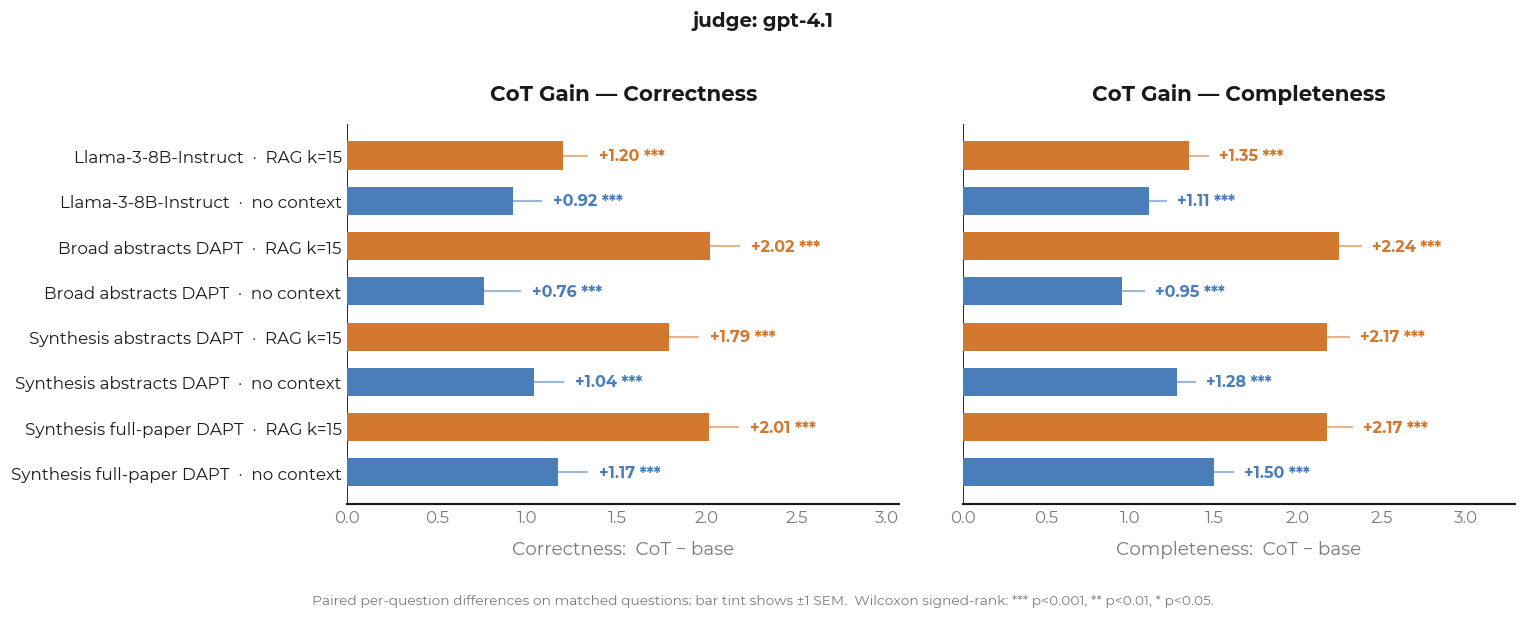

In [8]:
def paired_delta(base, cot, cond, task, judge):
    """(deltas, p) on matched questions where both models scored."""
    q = long_df[(long_df.condition == cond) & (long_df.judge == judge)]
    b = q[q.internal == base].set_index('q_idx')[task].dropna()
    c = q[q.internal == cot ].set_index('q_idx')[task].dropna()
    common = b.index.intersection(c.index)
    d = (c.loc[common] - b.loc[common]).values
    if len(d) < 3 or not np.any(d):
        return d, np.nan
    return d, wilcoxon(d).pvalue


def stars(p):
    if not np.isfinite(p):
        return ''
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 0.05 else 'n.s.'


delta_rows = []
for p_ in PAIRS:
    for cond in ('no_context', 'mmr'):
        for task in TASKS:
            for j in JUDGES:
                d, pv = paired_delta(p_['base'], p_['cot'], cond, task, j)
                delta_rows.append({'pair': p_['label'], 'base': p_['base'], 'cot': p_['cot'],
                                   'condition': cond, 'task': task, 'judge': j, 'n': len(d),
                                   'mean_delta': float(np.mean(d)) if len(d) else np.nan,
                                   'sem_delta': float(np.std(d, ddof=1)/np.sqrt(len(d))) if len(d) > 1 else np.nan,
                                   'p_value': pv, 'sig': stars(pv),
                                   'wins': int((d > 0).sum()), 'losses': int((d < 0).sum()),
                                   'ties': int((d == 0).sum())})
delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(os.path.join(FIGDIR, f'cot_paired_deltas_{TS}.csv'), index=False)
print(f'saved {FIGDIR}/cot_paired_deltas_{TS}.csv')

for JUDGE in JUDGES:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
    for ax, task in zip(axes, TASKS):
        labels, vals, sems, colors, sigs = [], [], [], [], []
        for p_ in PAIRS:
            for cond in ('mmr', 'no_context'):
                r = delta_df[(delta_df.pair == p_['label']) & (delta_df.condition == cond)
                             & (delta_df.task == task) & (delta_df.judge == JUDGE)].iloc[0]
                labels.append(f"{p_['label'].replace(chr(10), ' ')}  \u00b7  {COND_SHORT[cond]}")
                vals.append(r.mean_delta); sems.append(r.sem_delta)
                colors.append(COND_COLOR[cond]); sigs.append(r.sig)
        y = np.arange(len(vals))
        ax.barh(y, vals, height=0.62, color=colors, zorder=3)
        for yi, v, s_, c, sg in zip(y, vals, sems, colors, sigs):
            s_ = s_ if np.isfinite(s_) else 0.0
            ax.errorbar(v, yi, xerr=s_, fmt='none', ecolor=c, elinewidth=1.4,
                        capsize=0, alpha=0.55, zorder=4)
            xp = v + s_ + 0.06 if v >= 0 else v - s_ - 0.06
            ax.text(xp, yi, f'{v:+.2f} {sg}', va='center', ha='left' if v >= 0 else 'right',
                    fontsize=10.5, fontweight='bold', color=c, zorder=6)
        ax.axvline(0, color=INK, linewidth=1.2, zorder=2)
        ax.set_yticks(y); ax.set_yticklabels(labels)
        lo = min(0, min(vals) - 0.5); hi = max(vals) + 1.05
        ax.set_xlim(lo, hi); ax.invert_yaxis(); strip(ax)
        ax.set_xlabel(f'{TASK_TITLE[task]}:  CoT \u2212 base', labelpad=10)
        ax.set_title(f'CoT Gain \u2014 {TASK_TITLE[task]}', fontweight='bold', color=INK, pad=16)
    axes[1].set_yticklabels([])
    fig.suptitle(f'judge: {JUDGE}', fontweight='bold', color=INK, y=1.03, fontsize=13)
    fig.text(0.5, -0.05,
             'Paired per-question differences on matched questions; bar tint shows \u00b11 SEM.  '
             'Wilcoxon signed-rank: *** p<0.001, ** p<0.01, * p<0.05.',
             fontsize=9, color=MUTED, ha='center')
    fig.tight_layout(w_pad=3)
    save(fig, f'fig4_cot_deltas_{JUDGE}')
    plt.show()

## Figure 5 — Judge agreement (GPT-4.1 vs GPT-4o)

Evidence that the measurement instrument is stable: if two independent judges
rank models the same way, the reported differences are unlikely to be an artefact
of one judge's idiosyncrasies. Left: per-model means under each judge. Right:
per-question agreement per metric.

  saved figures_30e/fig5_judge_agreement_20260811_193811.{svg,png}


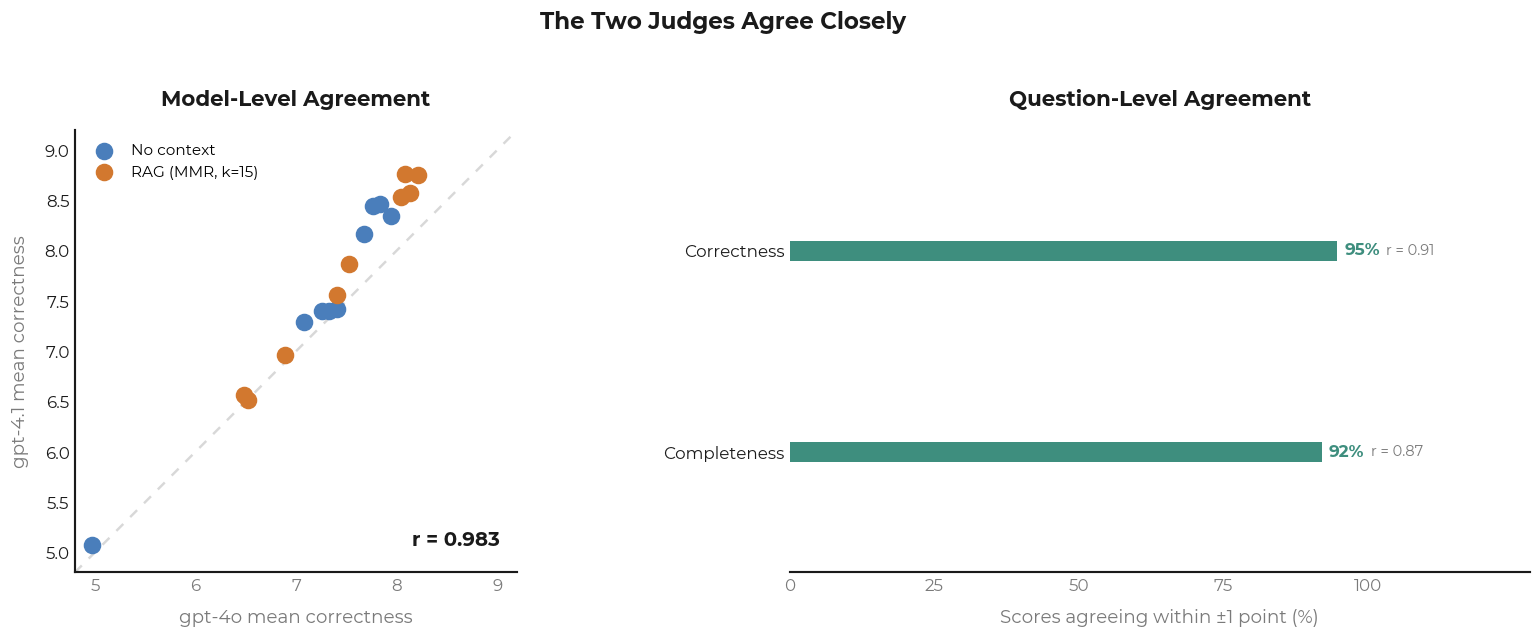

        task    n        r   within1
 Correctness 1790 0.912710 94.748603
Completeness 1790 0.873705 92.122905


In [9]:
if len(JUDGES) < 2:
    print(f"Only one judge ({JUDGES[0]}) - skipping the agreement figure.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))

    ax = axes[0]
    # Nothing excluded: all model x condition points are shown. (An earlier revision
    # dropped the base-LM no-context outlier; it is back in, since the corrected
    # re-judge in 30g is expected to move it.)
    EXCLUDE_POINTS = set()
    for cond in ('no_context', 'mmr'):
        pts = [(score(m.internal, cond, 'correctness', JUDGES[0])[0],
                score(m.internal, cond, 'correctness', JUDGES[1])[0])
               for _, m in AVAILABLE.iterrows()
               if (m.internal, cond) not in EXCLUDE_POINTS]
        ax.scatter([p[0] for p in pts], [p[1] for p in pts], s=110,
                   color=COND_COLOR[cond], label=COND_TITLE[cond], zorder=3)
    lims = (4.8, 9.2)
    ax.plot(lims, lims, linestyle=(0, (4, 4)), color=RULE, linewidth=1.6, zorder=2)
    ax.set_xlim(*lims); ax.set_ylim(*lims); ax.set_aspect('equal')
    ax.set_xlabel(f'{JUDGES[0]} mean correctness', labelpad=10)
    ax.set_ylabel(f'{JUDGES[1]} mean correctness', labelpad=10)
    ax.set_title('Model-Level Agreement', fontweight='bold', color=INK, pad=16)
    strip(ax); ax.spines['left'].set_visible(True); ax.spines['left'].set_color(INK)

    _mx = [score(m.internal, c, 'correctness', JUDGES[0])[0] for _, m in AVAILABLE.iterrows()
           for c in ('no_context','mmr') if (m.internal, c) not in EXCLUDE_POINTS]
    _my = [score(m.internal, c, 'correctness', JUDGES[1])[0] for _, m in AVAILABLE.iterrows()
           for c in ('no_context','mmr') if (m.internal, c) not in EXCLUDE_POINTS]
    _ok = np.isfinite(_mx) & np.isfinite(_my)
    _r = pearsonr(np.array(_mx)[_ok], np.array(_my)[_ok])[0]
    ax.text(0.96, 0.06, f'r = {_r:.3f}', transform=ax.transAxes, ha='right',
            fontsize=13, fontweight='bold', color=INK)
    ax.legend(loc='upper left')

    ax = axes[1]
    stats = []
    for task in TASKS:
        a = long_df[long_df.judge == JUDGES[0]].set_index(['internal','condition','q_idx'])[task]
        b = long_df[long_df.judge == JUDGES[1]].set_index(['internal','condition','q_idx'])[task]
        j = pd.concat([a.rename('a'), b.rename('b')], axis=1).dropna()
        stats.append({'task': TASK_TITLE[task], 'n': len(j), 'r': pearsonr(j.a, j.b)[0],
                      'within1': float((np.abs(j.a - j.b) <= 1).mean() * 100)})
    sdf = pd.DataFrame(stats)
    yy = np.arange(len(sdf))
    TEAL = '#3E8E7E'   # distinct from the condition colours; this panel is about judges
        # Only two rows share a tall panel here, so the same `height` fraction used by
    # the model charts would render far thicker. 0.10 lands on roughly the same
    # physical bar thickness (~0.25 in) as Figures 1-4.
    ax.barh(yy, sdf['within1'], height=0.10, color=TEAL, zorder=3)
    for i_, r_ in sdf.iterrows():
        ax.text(r_.within1 + 1.2, i_, f'{r_.within1:.0f}%', va='center',
                fontsize=11, fontweight='bold', color=TEAL)
        ax.text(r_.within1 + 8.5, i_, f'r = {r_.r:.2f}', va='center',
                fontsize=9.5, color=MUTED)
    ax.set_yticks(yy); ax.set_yticklabels(sdf['task'])
    ax.set_ylim(len(sdf) - 0.4, -0.6)     # inverted; span matches _yspan above
    ax.set_xlim(0, 128); ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xlabel('Scores agreeing within \u00b11 point (%)', labelpad=10)
    ax.set_title('Question-Level Agreement', fontweight='bold', color=INK, pad=16)
    strip(ax)

    fig.suptitle('The Two Judges Agree Closely', fontweight='bold', color=INK, y=1.03, fontsize=15)
    fig.tight_layout(w_pad=3)
    save(fig, 'fig5_judge_agreement')
    plt.show()

    sdf.to_csv(os.path.join(FIGDIR, f'judge_agreement_{TS}.csv'), index=False)
    print(sdf.to_string(index=False))

## Paper-ready results table

In [10]:
# One row per Table 1 model; mean +/- SEM per metric under each condition, per judge.
for JUDGE in JUDGES:
    out = []
    for _, m in AVAILABLE.iterrows():
        row = {'Model (Table 1)': m.table_label, 'DAPT corpus': m.dapt_corpus,
               'CoT FT': 'Yes' if m.cot_ft else 'No'}
        for cond in ('no_context', 'mmr'):
            for task in TASKS:
                mu, se = score(m.internal, cond, task, JUDGE)
                key = f"{'NoCtx' if cond == 'no_context' else 'RAG'} {task[:5]}"
                row[key] = f'{mu:.2f} \u00b1 {se:.2f}' if np.isfinite(mu) else '--'
        out.append(row)
    t = pd.DataFrame(out)
    t.to_csv(os.path.join(FIGDIR, f'paper_table_{JUDGE}_{TS}.csv'), index=False)
    with open(os.path.join(FIGDIR, f'paper_table_{JUDGE}_{TS}.tex'), 'w') as f:
        f.write(t.to_latex(index=False, escape=True,
                           caption=f'LLM-judge scores (mean $\\pm$ SEM) on 100 open-ended '
                                   f'zeolite questions. Judge: {JUDGE}.',
                           label=f'tab:openended_{JUDGE.replace(".", "")}'))
    print(f'\n=== judge: {JUDGE} ===')
    with pd.option_context('display.max_colwidth', 58, 'display.width', 250):
        print(t.to_string(index=False))
    print(f'saved {FIGDIR}/paper_table_{JUDGE}_{TS}.{{csv,tex}}')


=== judge: gpt-4o ===
                                           Model (Table 1)             DAPT corpus CoT FT NoCtx corre NoCtx compl   RAG corre   RAG compl
                                       Llama-3-8B-Instruct                    None     No 7.41 ± 0.16 8.63 ± 0.05 7.41 ± 0.18 8.17 ± 0.10
                              Llama-3-8B-Instruct + CoT FT                    None    Yes 7.94 ± 0.13 8.99 ± 0.01 8.08 ± 0.14 8.91 ± 0.04
         Llama-3-8B-Instruct, broad zeolite abstracts DAPT Broad zeolite abstracts     No 7.26 ± 0.18 8.56 ± 0.06 6.52 ± 0.20 6.93 ± 0.16
Llama-3-8B-Instruct, broad zeolite abstracts DAPT + CoT FT Broad zeolite abstracts    Yes 7.68 ± 0.17 8.90 ± 0.05 8.04 ± 0.16 8.85 ± 0.06
             Llama-3-8B-Instruct, synthesis abstracts DAPT     Synthesis abstracts     No 7.33 ± 0.18 8.65 ± 0.06 6.89 ± 0.18 7.31 ± 0.14
    Llama-3-8B-Instruct, synthesis abstracts DAPT + CoT FT     Synthesis abstracts    Yes 7.76 ± 0.14 8.98 ± 0.02 8.21 ± 0.12 8.92 ± 0.04
        Lla

In [11]:
print('=' * 78)
print('30e complete - no OpenAI API calls were made')
print('=' * 78)
print(f'source      : {JUDGE_FILE}   (schema {SCHEMA})')
print(f'judges      : {JUDGES}  -> one figure set per judge')
print(f'models      : {len(AVAILABLE)} of {len(MODEL_META)} Table 1 rows')
for _, r in MISSING.iterrows():
    print(f'   excluded : {r.table_label}')
print(f'\nfigures + tables in {FIGDIR}/ (suffix _{TS}):')
for f in sorted(os.listdir(FIGDIR)):
    if TS in f:
        print(f'   {f}')
print('=' * 78)

30e complete - no OpenAI API calls were made
source      : judge_results_23j_clean_20260803_201225.json   (schema clean-extraction-v1)
judges      : ['gpt-4o', 'gpt-4.1']  -> one figure set per judge
models      : 9 of 10 Table 1 rows
   excluded : GPT-5.2

figures + tables in figures_30e/ (suffix _20260811_193811):
   cot_paired_deltas_20260811_193811.csv
   fig1_correctness_gpt-4.1_20260811_193811.png
   fig1_correctness_gpt-4.1_20260811_193811.svg
   fig1_correctness_gpt-4o_20260811_193811.png
   fig1_correctness_gpt-4o_20260811_193811.svg
   fig2_all_metrics_gpt-4.1_20260811_193811.png
   fig2_all_metrics_gpt-4.1_20260811_193811.svg
   fig2_all_metrics_gpt-4o_20260811_193811.png
   fig2_all_metrics_gpt-4o_20260811_193811.svg
   fig3_cot_dumbbell_gpt-4.1_20260811_193811.png
   fig3_cot_dumbbell_gpt-4.1_20260811_193811.svg
   fig3_cot_dumbbell_gpt-4o_20260811_193811.png
   fig3_cot_dumbbell_gpt-4o_20260811_193811.svg
   fig4_cot_deltas_gpt-4.1_20260811_193811.png
   fig4_cot_deltas_g